In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
using ProgressMeter
using ColorSchemes
using LaTeXStrings
using Latexify

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [4]:
@latexrun beta_lb(l) = l < 0.5 ? 1 / (1-l) : 4*l

L"$\mathrm{beta}_{lb}\left( l \right) = \begin{cases}
\frac{1}{1 - l} & \text{if } l < 0.5\\
4 \cdot l & \text{otherwise}
\end{cases}$"

In [5]:
@latexrun beta_ub(l, p) = l / (p*(1-l)*(1-p*(1-l)))

L"$\mathrm{beta}_{ub}\left( l, p \right) = \frac{l}{p \cdot \left( 1 - l \right) \cdot \left( 1 - p \cdot \left( 1 - l \right) \right)}$"

In [6]:
function get_beta_range(l, p, n; betamax=1000.)
    lb = beta_lb(l)
    ub = beta_ub(l, p)
    if lb >= ub
        []
    else
        if ub == Inf
            ub = betamax
        end
        range(lb, ub, n)
    end
end

get_beta_range (generic function with 1 method)

In [33]:
@latexrun function k_max_squared(beta, l, p, roverD; s=+1)
    chi = 1 - 4*l/beta
    if chi < 0.
        return nothing
    end
    rootchi = sqrt(chi)
    fafa = (2*p-1)*chi+2*p*(1-2*(1-l)*p)*rootchi+(1-2*(1-l)*p)^2
    if fafa < 0.
        return nothing
    end
    roverD*((2*l)/(1-rootchi))*((2*p*rootchi + s*sqrt(fafa))/(p*(1-2*(1-l)*p-rootchi)))
end

L"$k_{max\_squared}\left( \beta, l, p, roverD; s = 1 \right) = roverD \cdot \frac{2 \cdot l}{1 - rootchi} \cdot \frac{2 \cdot p \cdot rootchi + s \cdot \sqrt{fafa}}{p \cdot \left( 1 - 2 \cdot \left( 1 - l \right) \cdot p - rootchi \right)}$"

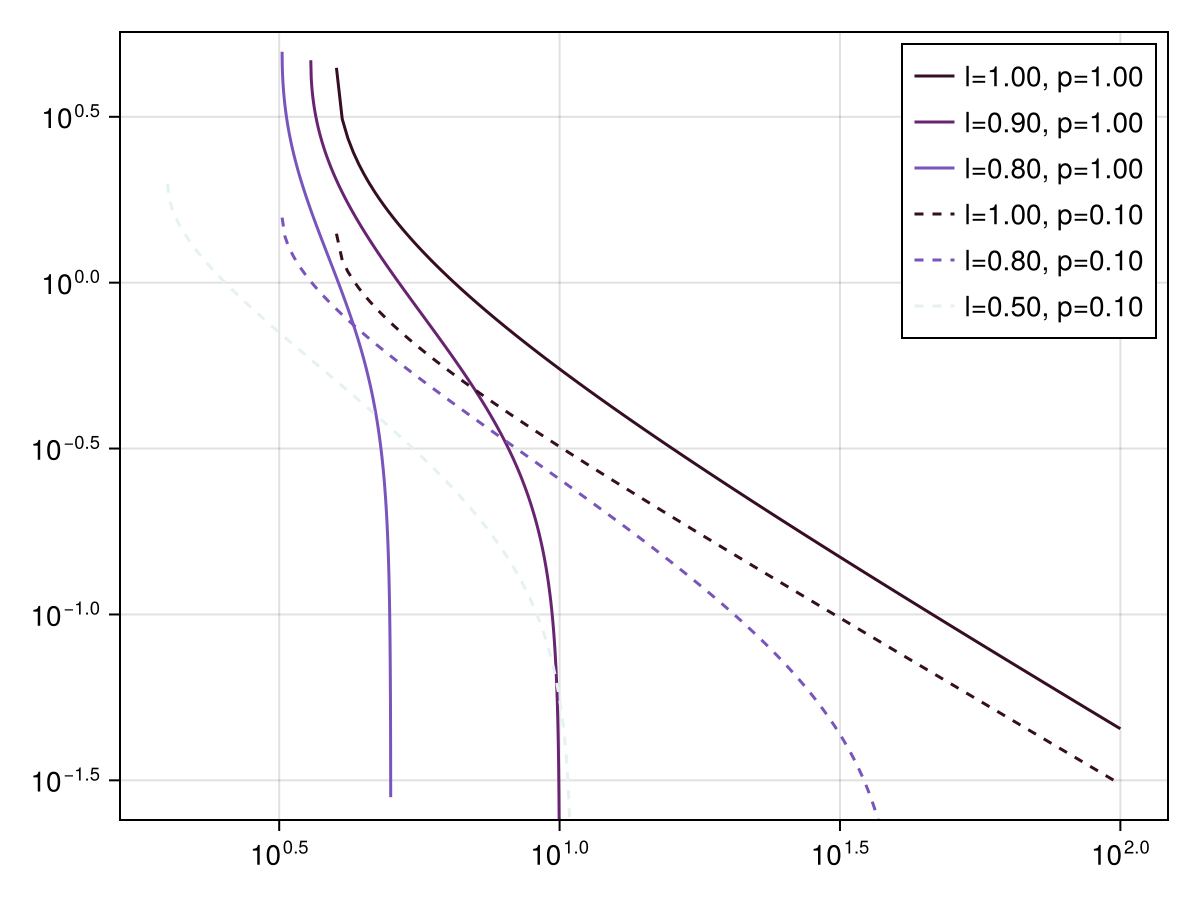

In [82]:
lps = [
    (1., 1.),
    (0.9, 1.),
    (0.8, 1.),
    # (1., 0.5),
    # (0.9, 0.5),
    # (0.8, 0.5),
    (1., 0.1),
    (0.8, 0.1),
    (0.5, 0.1),
]

lmin, lmax = extrema(getindex.(lps, 1))
ldelta = lmax - lmin
pmin, pmax = extrema(getindex.(lps, 2))
pdelta = pmax - pmin

fig = Figure()
ax = Axis(fig[1,1];
    yscale=log10,
    xscale=log10,
)

for (l, p) in lps
    betas = get_beta_range(l, p, 1000; betamax=100.)
    km2s = k_max_squared.(betas, l, p, 1.)
    Lms = MinimalModelV2.ksquared_to_L.(km2s)
    
    lines!(ax, betas, Lms;
        label=(@sprintf "l=%.2f, p=%.2f" l p),
        linestyle=p == 1 ? :solid : :dash,
        color=get(ColorSchemes.dense, (l - lmin) / ldelta)
    )
end

axislegend(ax)

fig

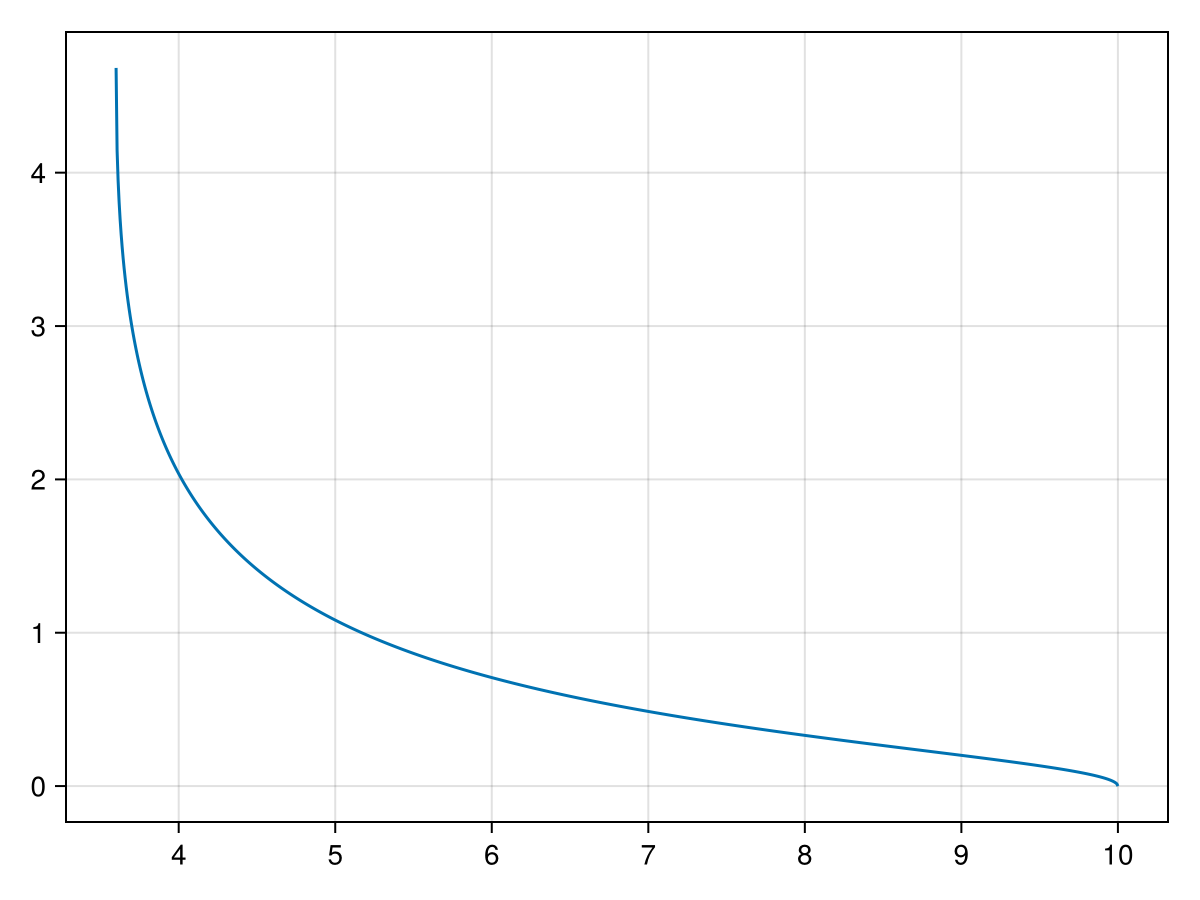

In [39]:
l = 0.9
p = 1.

betas = get_beta_range(l, p, 1000; betamax=1000.)
km2s = k_max_squared.(betas, l, p, 1.)
Lms = MinimalModelV2.ksquared_to_L.(km2s)
lines(betas, Lms)